Q1. Design and implement two image processing pipelines:

o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale

o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU

o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form

Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

Using images: 24
CPU Total Time      : 1.064744 s
GPU Total Time      : 0.514840 s
CPU Avg/Image       : 0.044364 s
GPU Avg/Image       : 0.021452 s
Speedup (CPU/GPU)   : 2.07x
                       Metric       CPU       GPU
0    Total Execution Time (s)  1.064744   0.51484
1  Average Time per Image (s)  0.044364  0.021452
2           Speedup (CPU/GPU)  2.070000         -


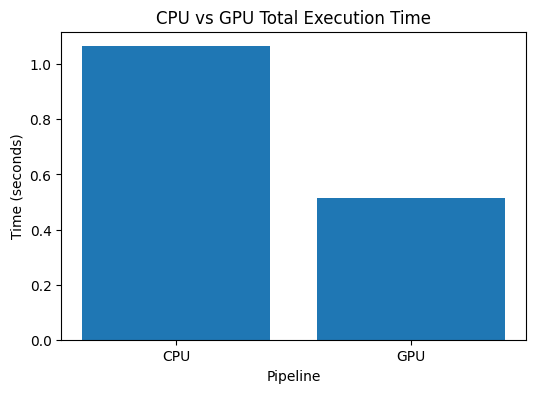

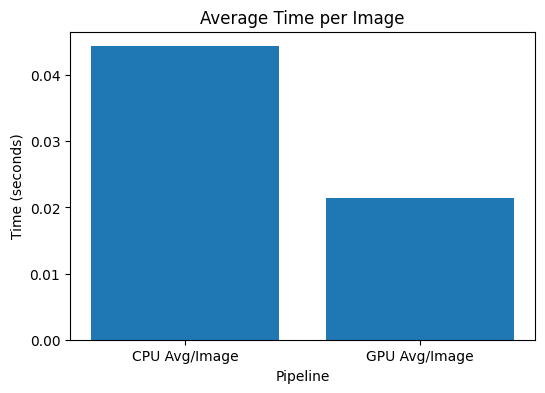

In [5]:
!pip install -q nvidia-dali-cuda110 opencv-python matplotlib pandas

import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = "/content/flower_photos"

paths = []

for r, _, files in os.walk(root):
    for f in files:
        if f.lower().endswith(".jpg"):
            paths.append(os.path.join(r, f))

paths = paths[:200]

if len(paths) < 15:
    raise ValueError("Dataset must contain at least 15 JPEG images.")

paths = paths[:150] if len(paths) >= 150 else paths
print("Using images:", len(paths))


def run_cpu(lst):
    t0 = time.time()
    out = []
    for fp in lst:
        img = cv2.imread(fp)
        img = cv2.resize(img, (512, 512))
        g   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        out.append(g)
    t1 = time.time()
    return t1 - t0, out


from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class Pipe(Pipeline):
    def __init__(self, bs, th, dev, files):
        super(Pipe, self).__init__(batch_size=bs, num_threads=th, device_id=dev, seed=12)
        self.files = files

    def define_graph(self):
        j, _ = fn.readers.file(files=self.files, random_shuffle=False)

        x = fn.decoders.image(j, device="mixed", output_type=types.RGB)
        x = fn.resize(x, resize_x=512, resize_y=512)
        x = fn.color_space_conversion(x, image_type=types.RGB, output_type=types.GRAY)

        return x


def run_gpu(lst, bs=16):
    pipe = Pipe(bs, 2, 0, lst)
    pipe.build()

    iters = int(np.ceil(len(lst) / bs))

    t0 = time.time()
    outs = []
    for _ in range(iters):
        o = pipe.run()
        outs.append(o)
    t1 = time.time()

    return t1 - t0, outs


t_cpu, out_cpu = run_cpu(paths)
t_gpu, out_gpu = run_gpu(paths, bs=16)

n = len(paths)

avg_cpu = t_cpu / n
avg_gpu = t_gpu / n
sp = t_cpu / t_gpu

print(f"CPU Total Time      : {t_cpu:.6f} s")
print(f"GPU Total Time      : {t_gpu:.6f} s")
print(f"CPU Avg/Image       : {avg_cpu:.6f} s")
print(f"GPU Avg/Image       : {avg_gpu:.6f} s")
print(f"Speedup (CPU/GPU)   : {sp:.2f}x")


tbl = pd.DataFrame({
    "Metric": [
        "Total Execution Time (s)",
        "Average Time per Image (s)",
        "Speedup (CPU/GPU)"
    ],
    "CPU": [
        round(t_cpu, 6),
        round(avg_cpu, 6),
        round(sp, 2)
    ],
    "GPU": [
        round(t_gpu, 6),
        round(avg_gpu, 6),
        "-"
    ]
})

print(tbl)


plt.figure(figsize=(6,4))
plt.bar(["CPU", "GPU"], [t_cpu, t_gpu])
plt.title("CPU vs GPU Total Execution Time")
plt.ylabel("Time (seconds)")
plt.xlabel("Pipeline")
plt.show()

print("\n")

plt.figure(figsize=(6,4))
plt.bar(["CPU Avg/Image", "GPU Avg/Image"], [avg_cpu, avg_gpu])
plt.title("Average Time per Image")
plt.ylabel("Time (seconds)")
plt.xlabel("Pipeline")
plt.show()

print("\n")

Q2. Implement a program that:

• Uses nvJPEG to decode a JPEG image

• Generates two grayscale outputs:

Direct grayscale conversion after decoding

Manually computed grayscale from RGB channels

• Perform this experiment on two different image resolutions.

• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

Using image: flower_photos/photo-1600703136783-bdb5ea365239.jpg


 Resolution: 256 x 256
Direct grayscale shape : (256, 256)
Manual grayscale shape : (256, 256)


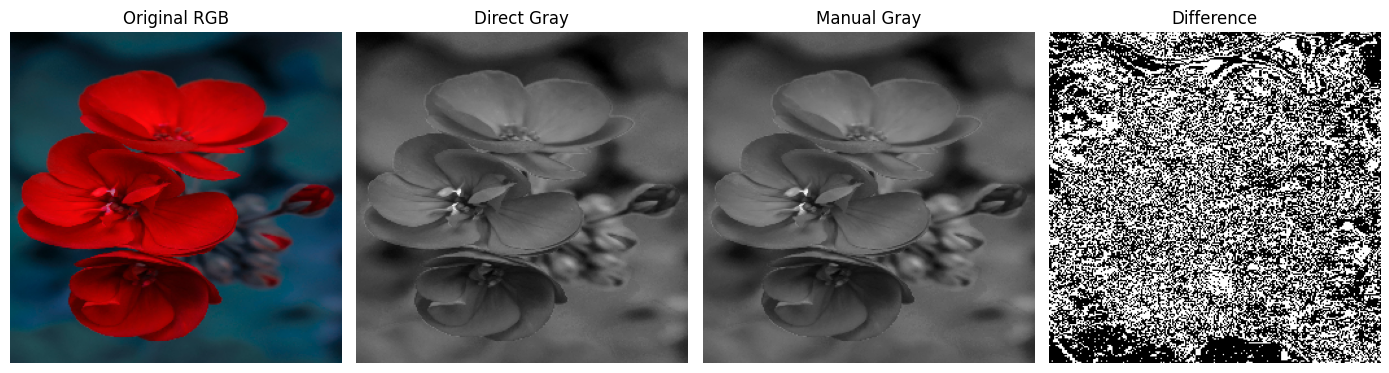



 Resolution: 1024 x 1024
Direct grayscale shape : (1024, 1024)
Manual grayscale shape : (1024, 1024)


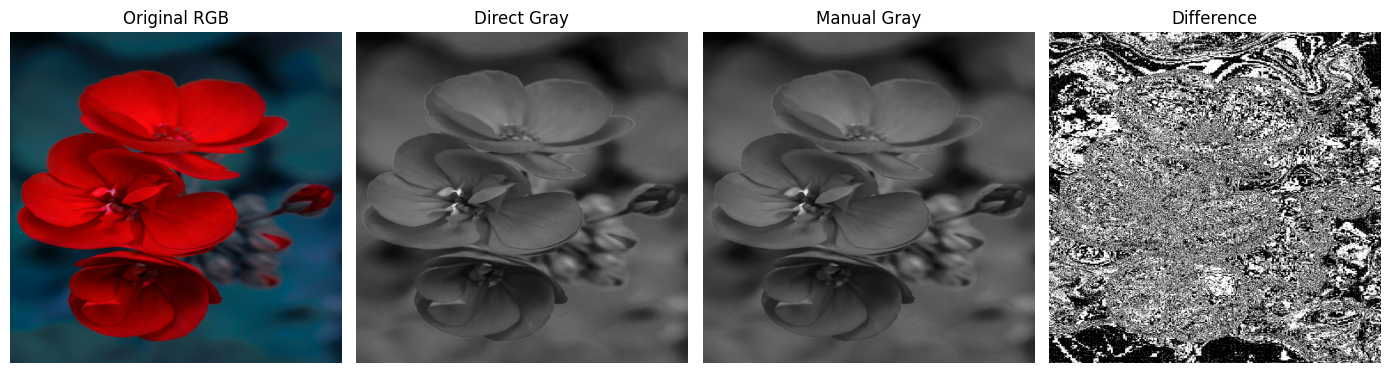

In [6]:
!pip install -q nvidia-dali-cuda110 opencv-python matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types


root_dir = "flower_photos"

files = []
for r, d, f in os.walk(root_dir):
    for name in f:
        if name.lower().endswith(".jpg"):
            files.append(os.path.join(r, name))

if len(files) == 0:
    raise ValueError("No JPEG images found in the folder.")

img_path = files[0]
print("Using image:", img_path)


class Pipe(Pipeline):
    def __init__(self, bs, th, dev, fp):
        super(Pipe, self).__init__(batch_size=bs, num_threads=th, device_id=dev)
        self.fp = fp

    def define_graph(self):
        j, _ = fn.readers.file(files=[self.fp])
        x = fn.decoders.image(j, device="mixed", output_type=types.RGB)
        return x


def load_gpu(p):
    pipe = Pipe(1, 2, 0, p)
    pipe.build()
    out = pipe.run()
    img = out[0].as_cpu().as_array()[0]
    return img


def gray_cv(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


def gray_manual(img):
    r = img[:, :, 0].astype(np.float32)
    g = img[:, :, 1].astype(np.float32)
    b = img[:, :, 2].astype(np.float32)

    y = 0.299 * r + 0.587 * g + 0.114 * b
    return np.clip(y, 0, 255).astype(np.uint8)


sizes = [(256, 256), (1024, 1024)]

img = load_gpu(img_path)

for s in sizes:
    print("\n")
    print(f" Resolution: {s[0]} x {s[1]}")

    img_r = cv2.resize(img, s)

    g1 = gray_cv(img_r)
    g2 = gray_manual(img_r)

    d  = cv2.absdiff(g1, g2)

    print("Direct grayscale shape :", g1.shape)
    print("Manual grayscale shape :", g2.shape)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.title("Original RGB")
    plt.imshow(img_r)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Direct Gray")
    plt.imshow(g1, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Manual Gray")
    plt.imshow(g2, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Difference")
    plt.imshow(d, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Q3. Design and compare two preprocessing pipelines:
1. Pipeline A (Hybrid Approach)

Decode images using OpenCV (CPU)

Transfer images to GPU

Perform resizing and normalization using CUDA/CuPy/PyTorch

2. Pipeline B (DALI-Based Approach)

 Use NVIDIA DALI for image loading

Perform GPU-based decoding (nvJPEG internally)

Apply resizing and normalization on GPU


•Use a dataset of at least 20 images and experiment with different batch

sizes and
image resolutions. Measure total execution time for both pipelines

• Compute throughput (images per second)

• Compare efficiency and resource utilization

• Present results using tables/graphs

Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

In [7]:
!pip install -q nvidia-dali-cuda110 opencv-python torch torchvision pandas matplotlib


In [8]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz

--2026-05-07 12:46:15--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M  19.3MB/s    in 12s     

2026-05-07 12:46:28 (17.5 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]



Total images: 200

Batch: 8, Resolution: (256, 256)

Batch: 8, Resolution: (512, 512)

Batch: 16, Resolution: (256, 256)

Batch: 16, Resolution: (512, 512)

===== RESULTS =====
   Batch Size  Resolution  Pipeline A Time  Pipeline B Time  Throughput A  \
0           8  (256, 256)         0.371688         0.150311    538.085867   
1           8  (512, 512)         0.676196         0.154059    295.772189   
2          16  (256, 256)         0.352032         0.138114    568.130257   
3          16  (512, 512)         0.896621         0.148939    223.059750   

   Throughput B  
0   1330.574669  
1   1298.202488  
2   1448.074380  
3   1342.832582  


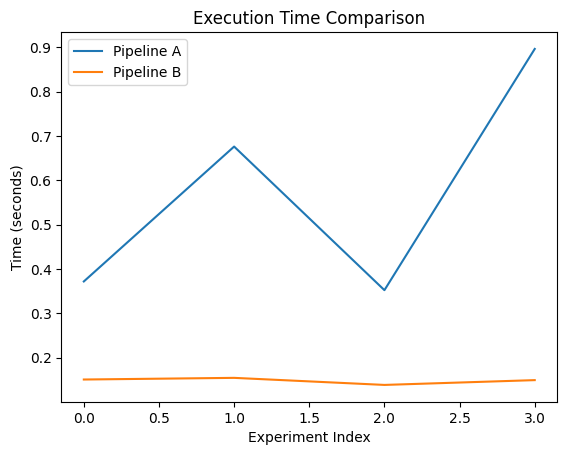

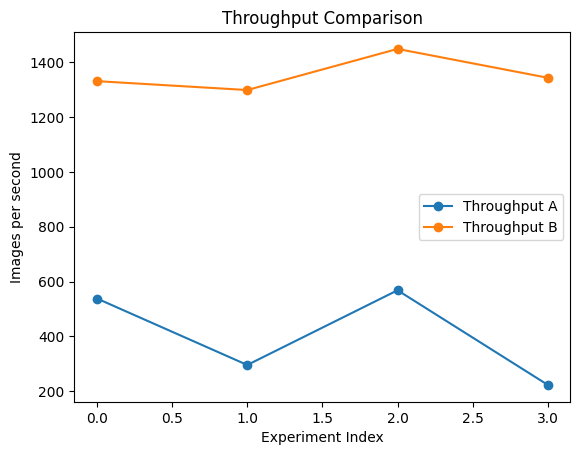

In [9]:
!pip install -q nvidia-dali-cuda110 opencv-python torch torchvision pandas matplotlib

import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

dev = 'cuda' if torch.cuda.is_available() else 'cpu'


root = "/content/flower_photos"

paths = []
for d in os.listdir(root):
    p = os.path.join(root, d)
    if os.path.isdir(p):
        for f in os.listdir(p):
            if f.endswith(".jpg"):
                paths.append(os.path.join(p, f))

paths = paths[:200]
print("Total images:", len(paths))


def run_A(lst, bs, res):
    t0 = time.time()

    for i in range(0, len(lst), bs):
        batch = lst[i:i+bs]
        buf = []

        for fp in batch:
            img = cv2.imread(fp)
            img = cv2.resize(img, res)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            buf.append(img)

        buf = np.stack(buf)

        ten = torch.tensor(buf).float().to(dev)
        ten = ten / 255.0

    torch.cuda.synchronize()
    t1 = time.time()

    return t1 - t0


class Pipe(Pipeline):
    def __init__(self, bs, th, dev_id, files, res):
        super(Pipe, self).__init__(bs, th, dev_id)
        self.files = files
        self.res = res

    def define_graph(self):
        j, _ = fn.readers.file(files=self.files)

        x = fn.decoders.image(j, device="mixed", output_type=types.RGB)
        x = fn.resize(x, resize_x=self.res[0], resize_y=self.res[1])

        x = fn.crop_mirror_normalize(
            x,
            dtype=types.FLOAT,
            output_layout="HWC",
            mean=[0.0, 0.0, 0.0],
            std=[255.0, 255.0, 255.0]
        )

        return x


def run_B(lst, bs, res):
    pipe = Pipe(bs, 2, 0, lst, res)
    pipe.build()

    t0 = time.time()

    for _ in range(len(lst)//bs + 1):
        pipe.run()

    t1 = time.time()
    return t1 - t0


batches = [8, 16]
sizes = [(256,256), (512,512)]

rows = []

run_A(paths[:32], 8, (256,256))
run_B(paths[:32], 8, (256,256))


for b in batches:
    for s in sizes:
        print(f"\nBatch: {b}, Resolution: {s}")

        ta = run_A(paths, b, s)
        tb = run_B(paths, b, s)

        thr_a = len(paths) / ta
        thr_b = len(paths) / tb

        rows.append({
            "Batch Size": b,
            "Resolution": str(s),
            "Pipeline A Time": ta,
            "Pipeline B Time": tb,
            "Throughput A": thr_a,
            "Throughput B": thr_b
        })


df = pd.DataFrame(rows)
print(df)


plt.figure()
plt.plot(df["Pipeline A Time"], label="Pipeline A")
plt.plot(df["Pipeline B Time"], label="Pipeline B")
plt.title("Execution Time Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

print("\n")

plt.figure()
plt.plot(df["Throughput A"], marker='o', label="Throughput A")
plt.plot(df["Throughput B"], marker='o', label="Throughput B")
plt.title("Throughput Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Images per second")
plt.legend()
plt.show()

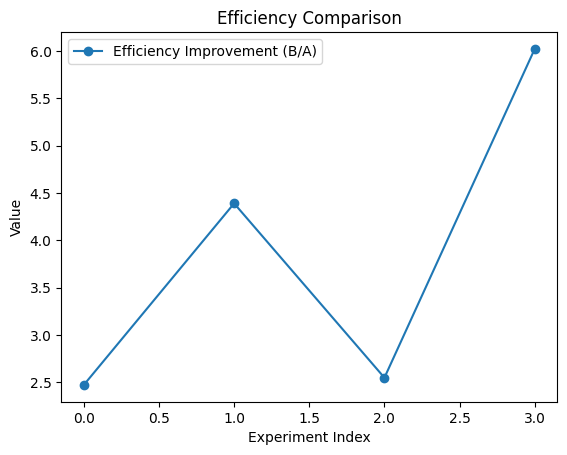

In [10]:

df["Efficiency Improvement"] = df["Throughput B"] / df["Throughput A"]

plt.figure()

plt.plot(df["Efficiency Improvement"], marker='o', label="Efficiency Improvement (B/A)")
plt.title("Efficiency Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Value")
plt.legend()
plt.show()